#  Customer Intelligence System


## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Ensemble
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset


In [2]:

df = pd.read_csv('Country-data.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (167, 10)

First 5 rows:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Step 3: Exploratory Data Analysis (EDA)

In [3]:

print('Dataset Info:')
df.info()

Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:

print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


In [5]:

print('Missing Values:')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Total missing: 0


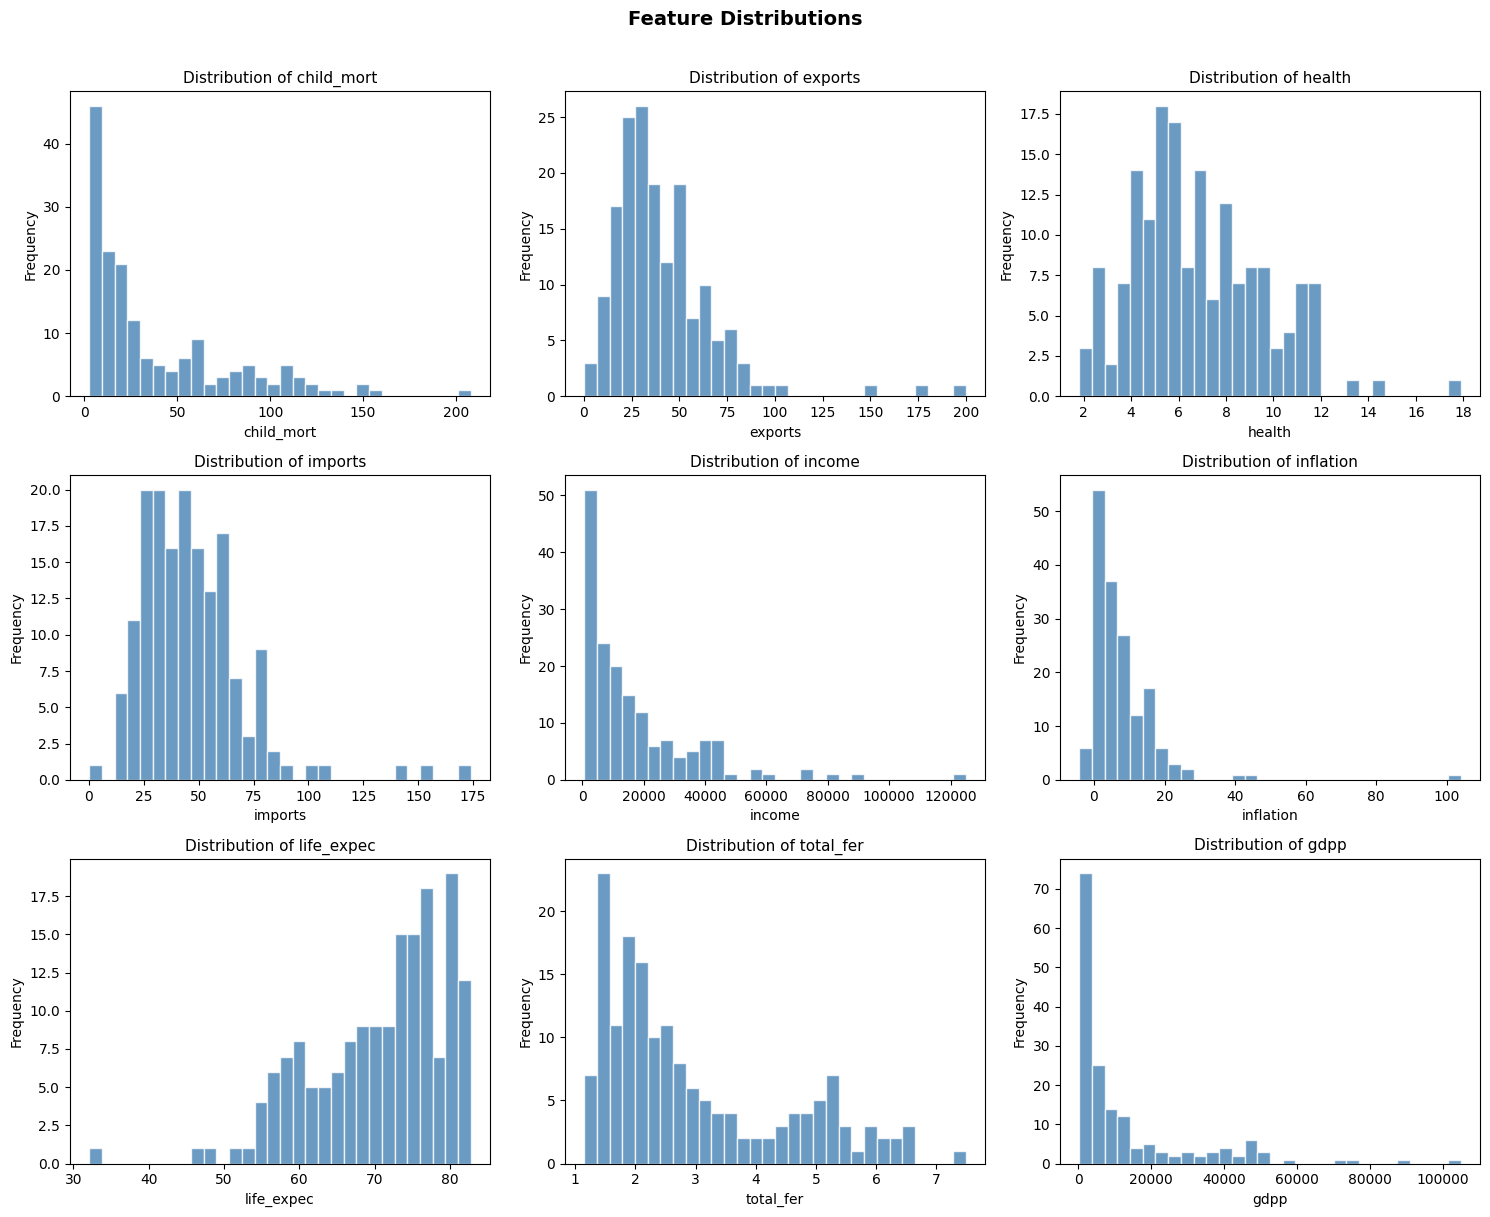

In [6]:

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

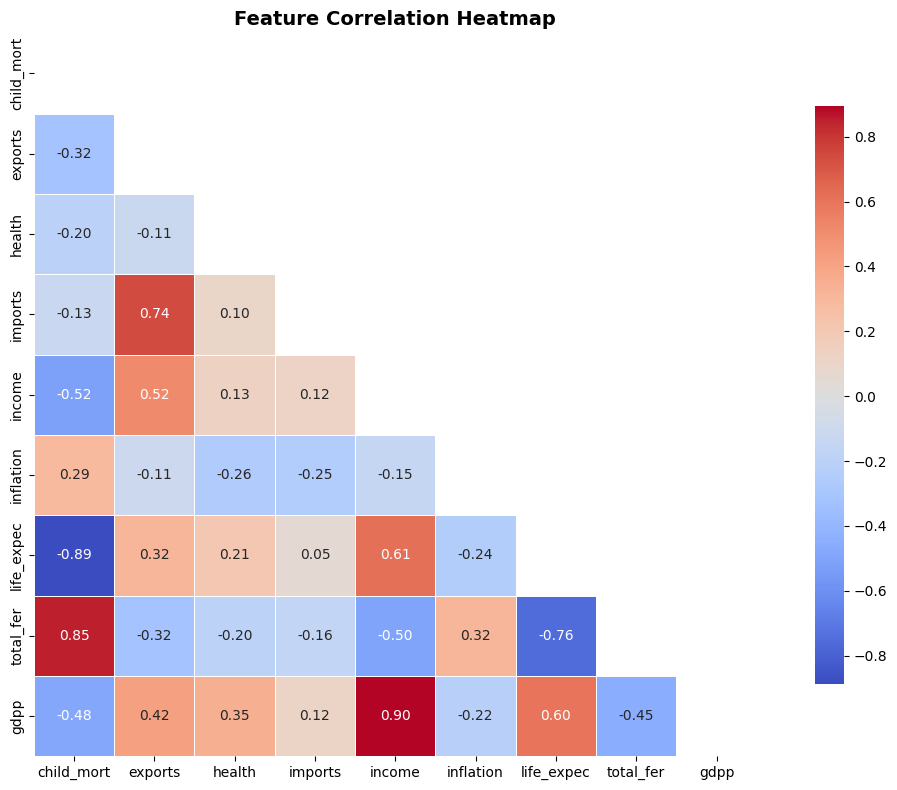

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

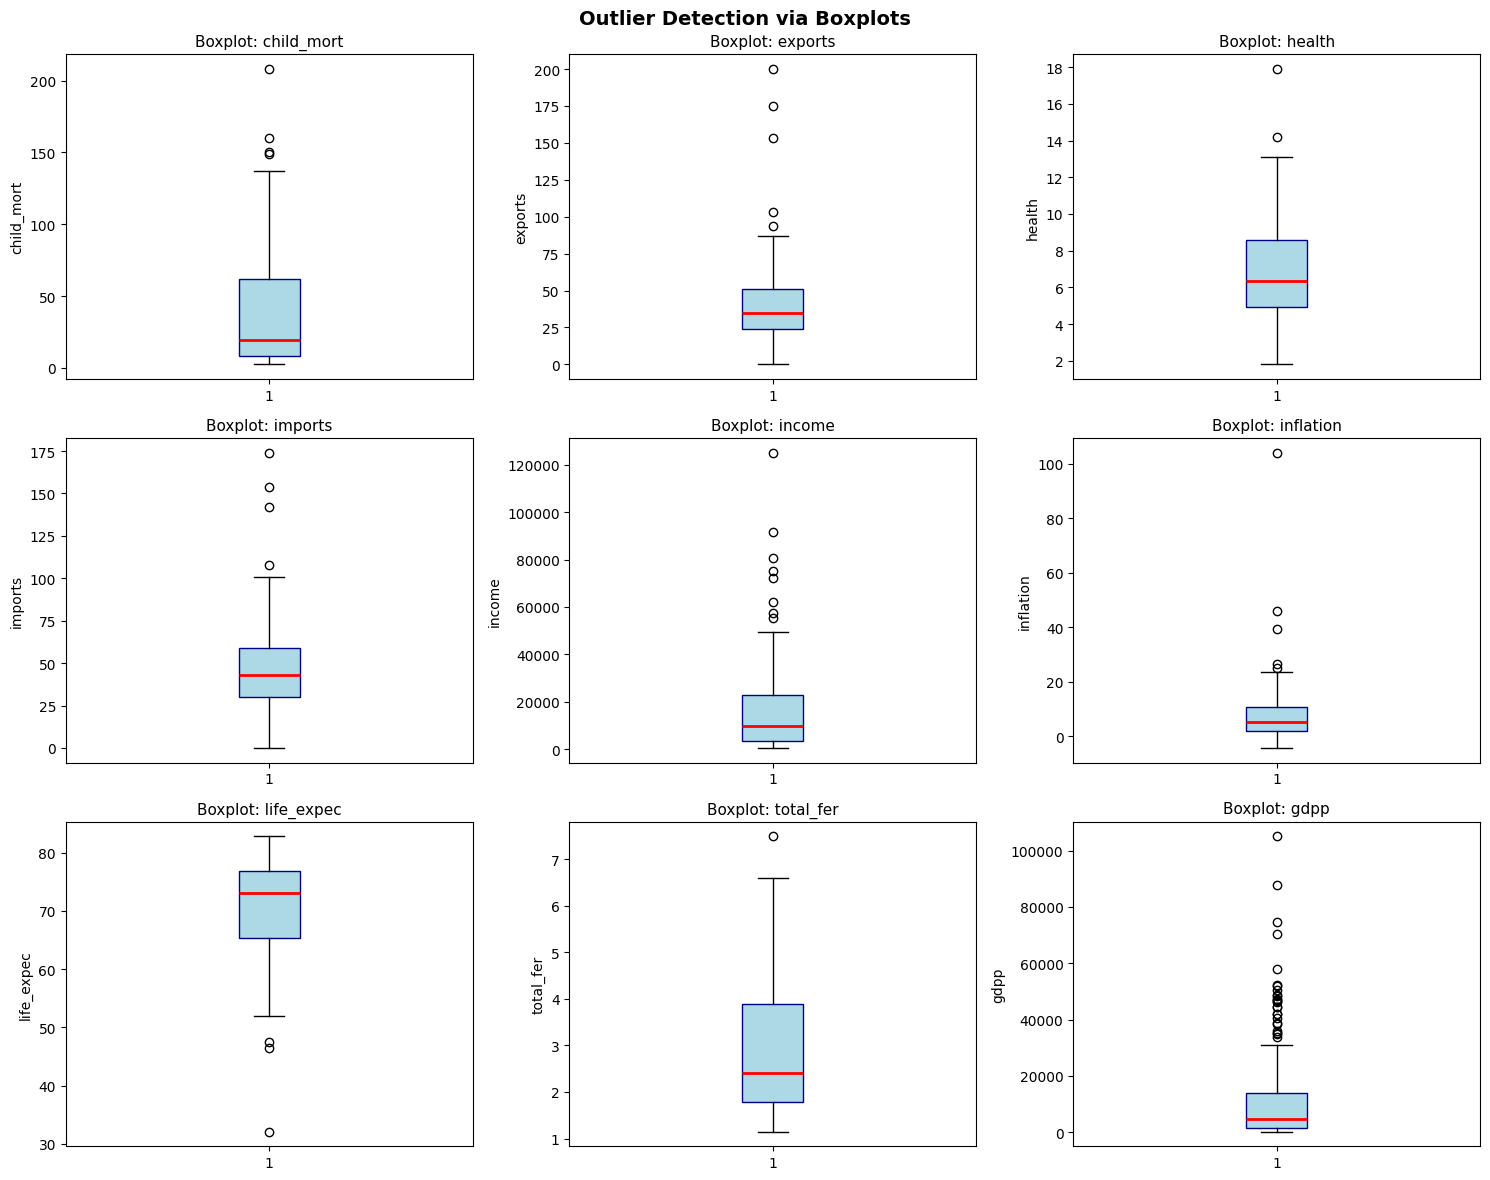

In [8]:
# Boxplots to detect outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_ylabel(col)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection via Boxplots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [9]:
# Separate country name column
country_names = df['country'].values
features = df.drop(columns=['country'])

# Scale features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

print(' Features scaled. Shape:', features_scaled.shape)
features_scaled_df.head()

 Features scaled. Shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Step 5: Clustering — K-Means


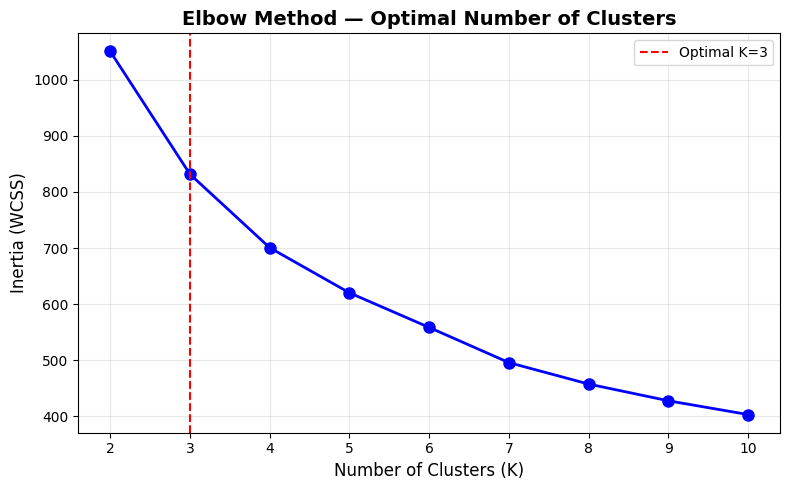

In [10]:
# Elbow Method to find optimal K
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

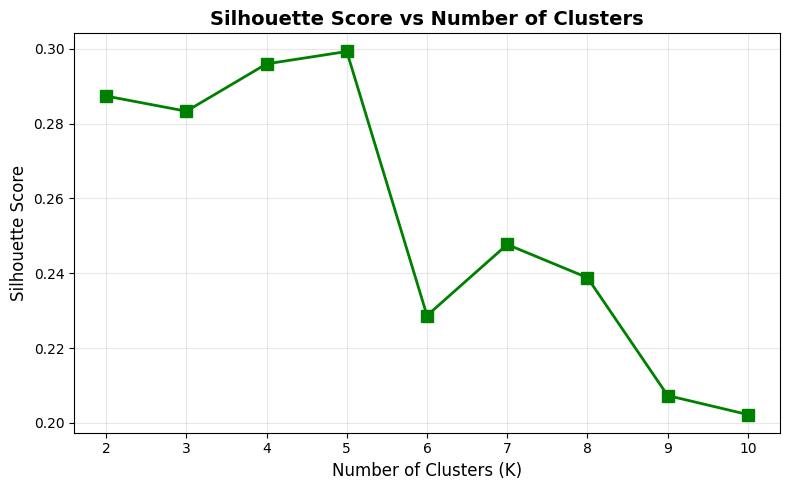

Best K by Silhouette Score: 5 (Score: 0.2993)


In [11]:

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, 'gs-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(sil_scores)]
print(f'Best K by Silhouette Score: {best_k} (Score: {max(sil_scores):.4f})')

In [12]:
# Apply K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(features_scaled)

df['KMeans_Cluster'] = kmeans_labels
print('K-Means Cluster Distribution:')
print(df['KMeans_Cluster'].value_counts())
print(f'\nSilhouette Score (K=3): {silhouette_score(features_scaled, kmeans_labels):.4f}')

K-Means Cluster Distribution:
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64

Silhouette Score (K=3): 0.2833


PCA Explained Variance: PC1=46.0%, PC2=17.2%


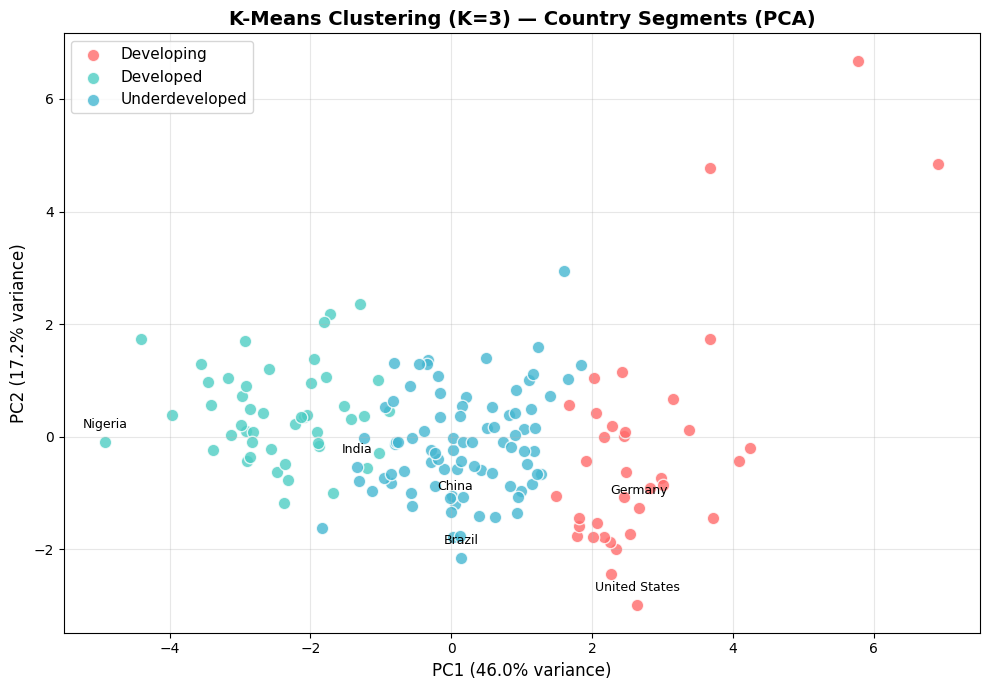

In [13]:

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

print(f'PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

# Visualize K-Means clusters
cluster_names = {0: 'Developing', 1: 'Developed', 2: 'Underdeveloped'}
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

plt.figure(figsize=(10, 7))
for c in range(3):
    mask = kmeans_labels == c
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                c=colors[c], label=cluster_names[c], s=80, alpha=0.8, edgecolors='white')

# Mark some important countries
highlight_countries = ['United States', 'India', 'China', 'Nigeria', 'Germany', 'Brazil']
for i, country in enumerate(country_names):
    if country in highlight_countries:
        plt.annotate(country, (pca_result[i, 0], pca_result[i, 1]),
                     fontsize=9, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('K-Means Clustering (K=3) — Country Segments (PCA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

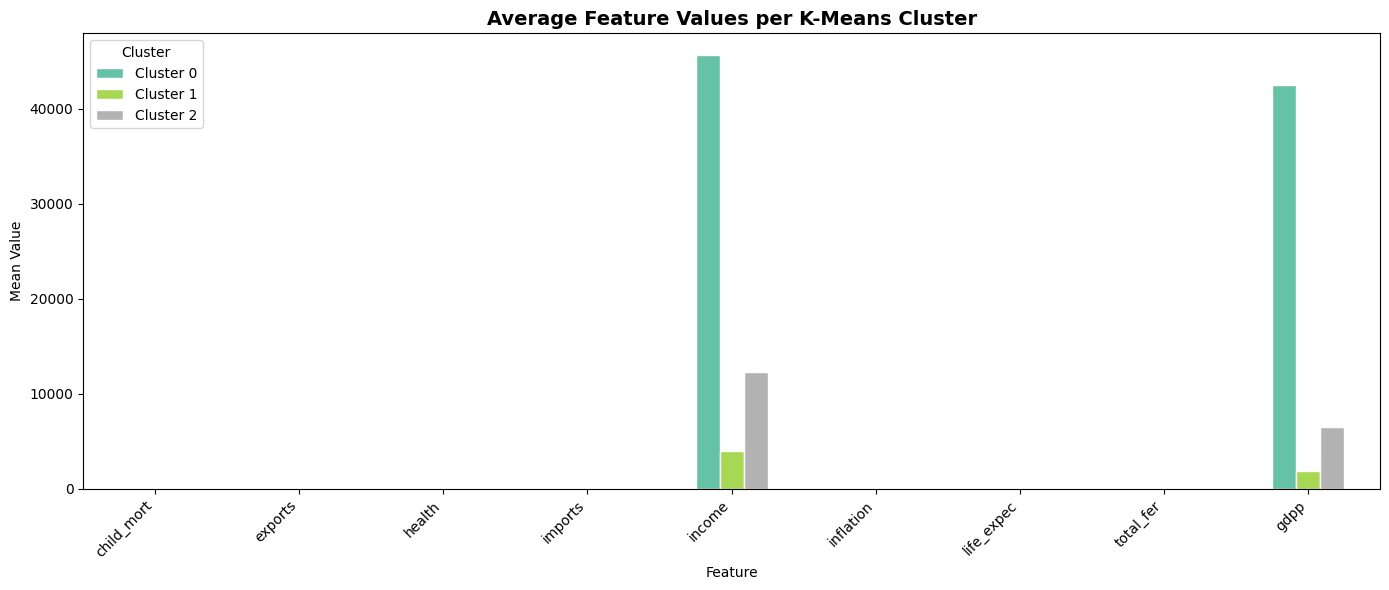


Cluster Profiles:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
Cluster 1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
Cluster 2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [14]:
# Cluster Profiles — Average features per cluster
cluster_profile = df.groupby('KMeans_Cluster')[numerical_cols].mean().round(2)
cluster_profile.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(14, 6))
cluster_profile.T.plot(kind='bar', ax=plt.gca(), colormap='Set2', edgecolor='white')
plt.title('Average Feature Values per K-Means Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print('\nCluster Profiles:')
cluster_profile

## Step 6: Clustering — DBSCAN

In [15]:
# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(features_scaled)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN Results:')
print(f'  Number of clusters found: {n_clusters_db}')
print(f'  Noise points (outliers): {n_noise}')
print(f'  Cluster label distribution:')
print(pd.Series(dbscan_labels).value_counts().to_string())

# Silhouette score (only if more than 1 cluster found)
if n_clusters_db > 1:
    mask_valid = dbscan_labels != -1
    sil_db = silhouette_score(features_scaled[mask_valid], dbscan_labels[mask_valid])
    print(f'\nSilhouette Score (DBSCAN, excl. noise): {sil_db:.4f}')

DBSCAN Results:
  Number of clusters found: 1
  Noise points (outliers): 30
  Cluster label distribution:
 0    137
-1     30


C:\Users\Dmiz\AppData\Local\Temp\ipykernel_20336\217368718.py:11: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(pca_result[mask, 0], pca_result[mask, 1],


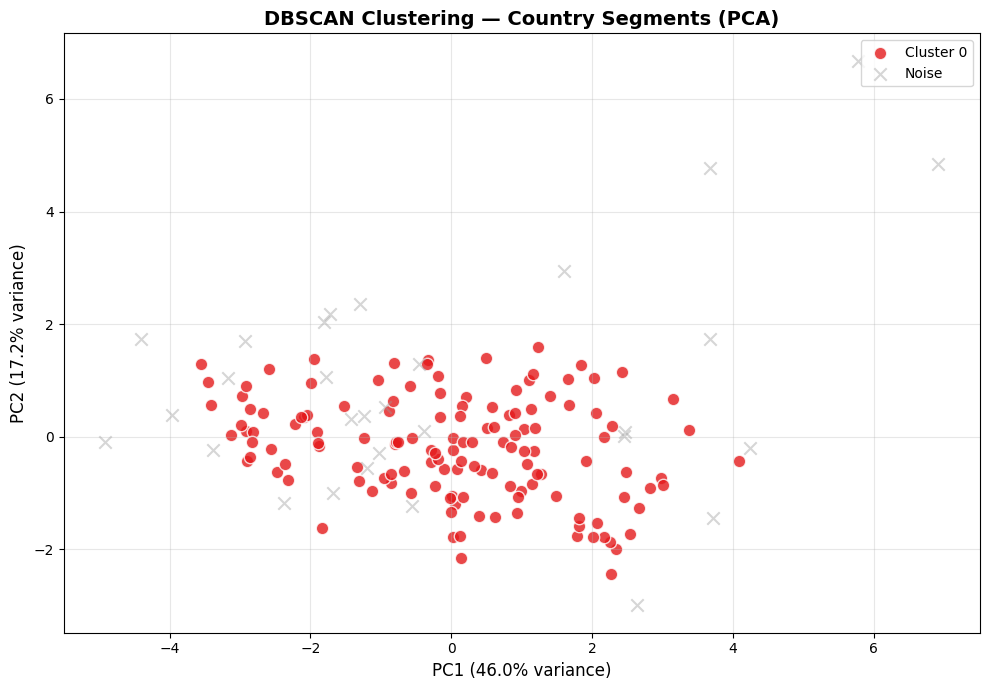

In [16]:
# Visualize DBSCAN clusters
plt.figure(figsize=(10, 7))
unique_labels = set(dbscan_labels)
color_palette = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, color_palette):
    mask = dbscan_labels == label
    label_name = f'Noise' if label == -1 else f'Cluster {label}'
    marker = 'x' if label == -1 else 'o'
    alpha = 0.4 if label == -1 else 0.8
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                c=[color], label=label_name, s=80, marker=marker, alpha=alpha, edgecolors='white')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
plt.title('DBSCAN Clustering — Country Segments (PCA)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 7: Create Labels for Classification


In [17]:
# Use KMeans labels as classification target
X = features_scaled
y = kmeans_labels  # 0, 1, 2 representing country development tiers

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'\nClass distribution in train: {np.bincount(y_train)}')
print(f'Class distribution in test:  {np.bincount(y_test)}')

Training samples: 133
Testing samples:  34

Class distribution in train: [29 37 67]
Class distribution in test:  [ 7 10 17]


## Step 8: Classification Models

In [18]:
# Helper function to evaluate and plot confusion matrix
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f'\n{'='*50}')
    print(f'  {model_name}')
    print(f'{'='*50}')
    print(f'Test Accuracy:       {acc*100:.2f}%')
    print(f'CV Accuracy (mean):  {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2']))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
                yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'],
                linewidths=0.5)
    plt.title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    return acc, cv_scores.mean()

results = {}


  Logistic Regression
Test Accuracy:       100.00%
CV Accuracy (mean):  93.99% ± 3.90%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



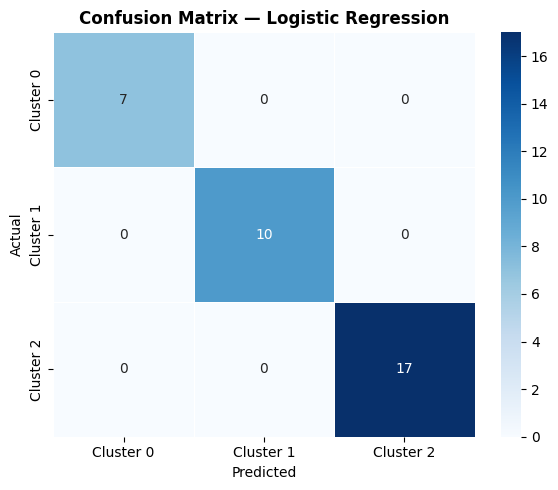

In [19]:

lr = LogisticRegression(max_iter=1000, random_state=42)
acc_lr, cv_lr = evaluate_model(lr, X_train, X_test, y_train, y_test, 'Logistic Regression')
results['Logistic Regression'] = {'Test Acc': acc_lr, 'CV Acc': cv_lr}


  Decision Tree
Test Accuracy:       94.12%
CV Accuracy (mean):  90.97% ± 1.88%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       0.88      1.00      0.93         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



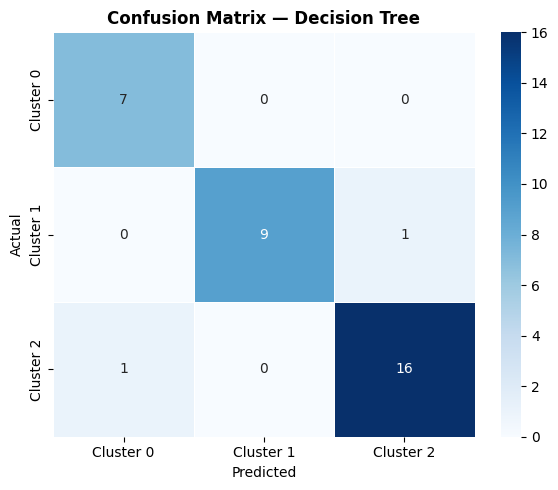

In [20]:

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
acc_dt, cv_dt = evaluate_model(dt, X_train, X_test, y_train, y_test, 'Decision Tree')
results['Decision Tree'] = {'Test Acc': acc_dt, 'CV Acc': cv_dt}

## Step 9: Ensemble Learning


  Random Forest
Test Accuracy:       100.00%
CV Accuracy (mean):  93.19% ± 3.75%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      1.00      1.00        10
   Cluster 2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



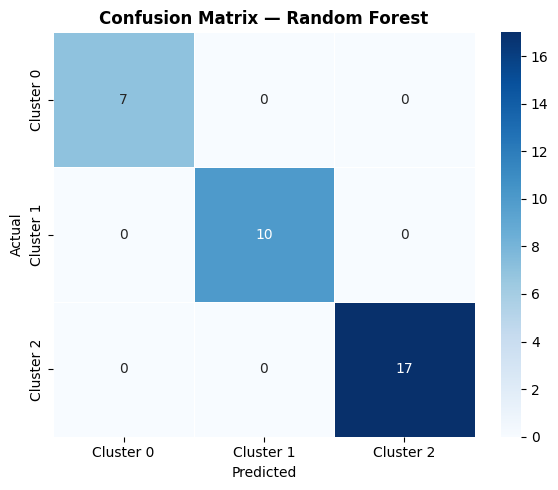

In [21]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
acc_rf, cv_rf = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')
results['Random Forest'] = {'Test Acc': acc_rf, 'CV Acc': cv_rf}

C:\Users\Dmiz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:02:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dmiz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:02:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Dmiz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:02:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are


  XGBoost
Test Accuracy:       97.06%
CV Accuracy (mean):  93.93% ± 3.92%

Classification Report:
              precision    recall  f1-score   support

   Cluster 0       1.00      1.00      1.00         7
   Cluster 1       1.00      0.90      0.95        10
   Cluster 2       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



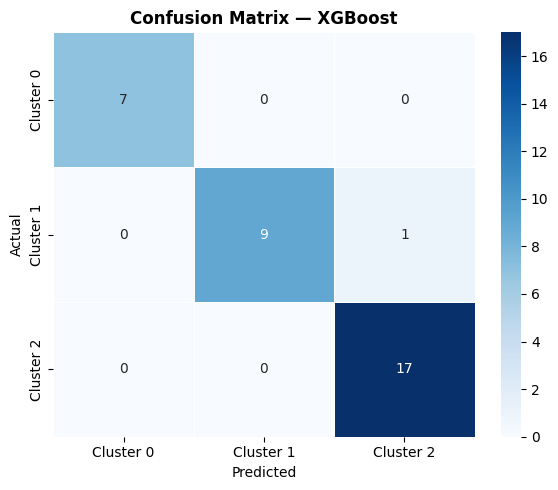

In [22]:
# XGBoost 
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                     use_label_encoder=False, eval_metric='mlogloss', random_state=42)
acc_xgb, cv_xgb = evaluate_model(xgb, X_train, X_test, y_train, y_test, 'XGBoost')
results['XGBoost'] = {'Test Acc': acc_xgb, 'CV Acc': cv_xgb}

## Step 10: Model Comparison

In [23]:
# Summary Table
results_df = pd.DataFrame(results).T
results_df.columns = ['Test Accuracy', 'CV Accuracy']
results_df = results_df.sort_values('Test Accuracy', ascending=False)
results_df['Test Accuracy (%)'] = (results_df['Test Accuracy'] * 100).round(2)
results_df['CV Accuracy (%)'] = (results_df['CV Accuracy'] * 100).round(2)
print('\n Model Performance Summary:')
print(results_df[['Test Accuracy (%)', 'CV Accuracy (%)']].to_string())


 Model Performance Summary:
                     Test Accuracy (%)  CV Accuracy (%)
Logistic Regression             100.00            93.99
Random Forest                   100.00            93.19
XGBoost                          97.06            93.93
Decision Tree                    94.12            90.97


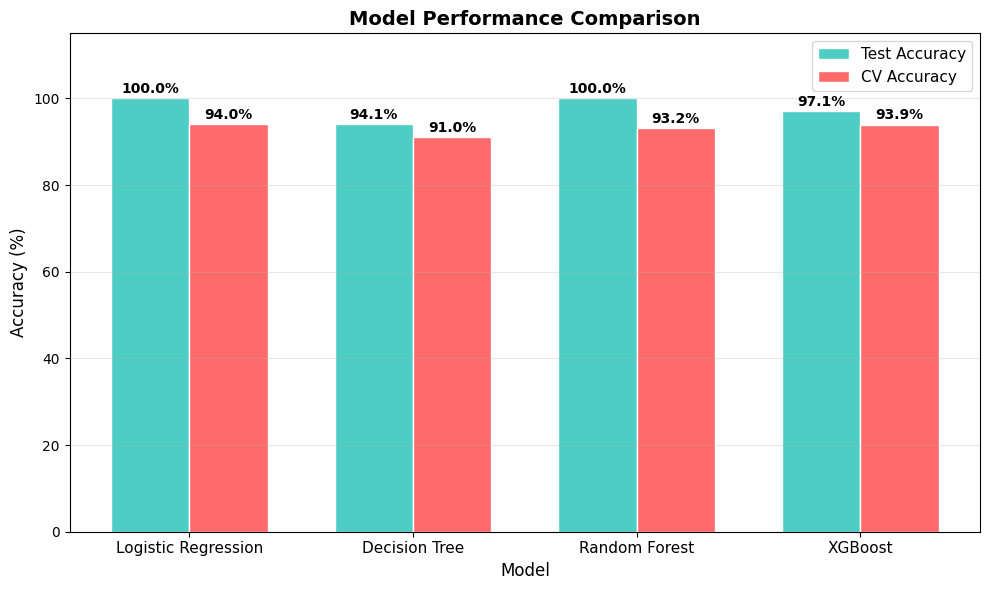

In [24]:
# Bar Chart Comparison
fig, ax = plt.subplots(figsize=(10, 6))

models = list(results.keys())
test_accs = [results[m]['Test Acc'] * 100 for m in models]
cv_accs = [results[m]['CV Acc'] * 100 for m in models]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='#4ECDC4', edgecolor='white')
bars2 = ax.bar(x + width/2, cv_accs, width, label='CV Accuracy', color='#FF6B6B', edgecolor='white')

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

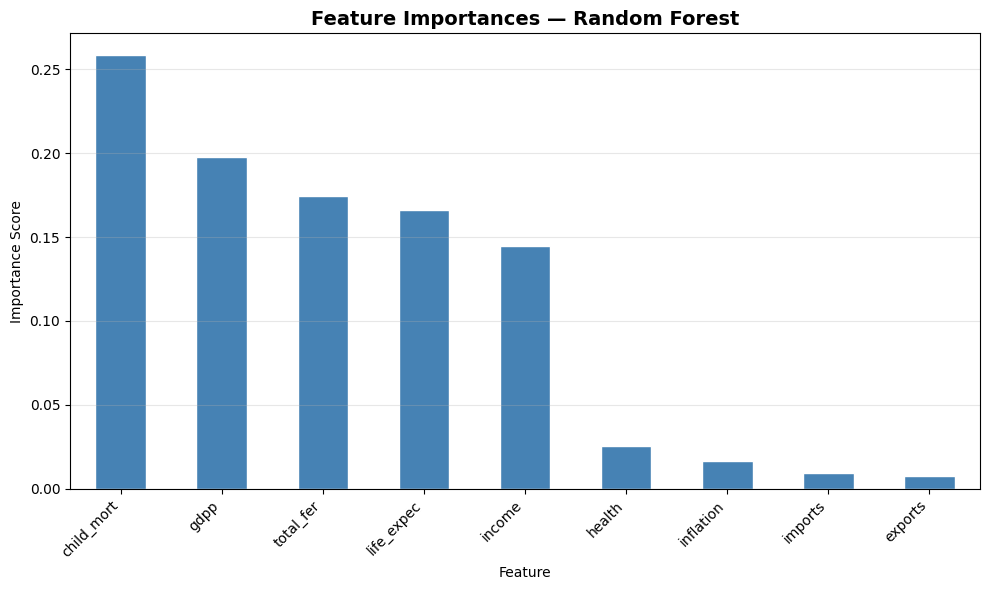


Top 3 Most Important Features:
child_mort    0.258356
gdpp          0.197672
total_fer     0.174131


In [25]:
# Feature Importance from Random Forest
feature_imp = pd.Series(rf.feature_importances_, index=features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 3 Most Important Features:')
print(feature_imp.head(3).to_string())

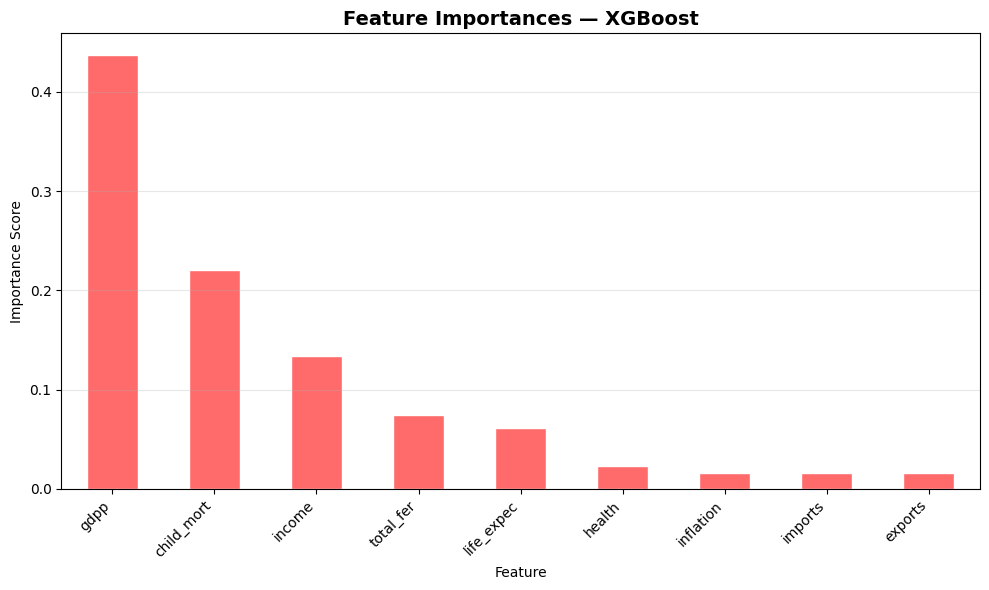

In [26]:
# Feature Importance from XGBoost
xgb_imp = pd.Series(xgb.feature_importances_, index=features.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_imp.plot(kind='bar', color='#FF6B6B', edgecolor='white')
plt.title('Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11: Country Intelligence Insights

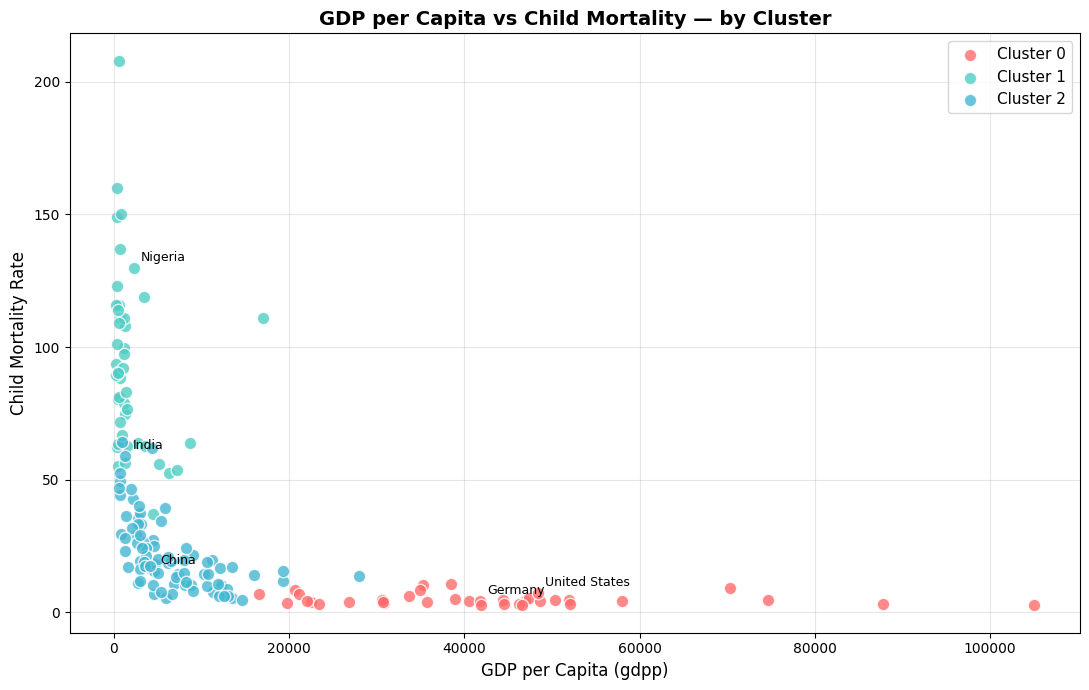

In [27]:
# Add country names back and show cluster assignments
results_full = df.copy()
results_full['country'] = country_names

# GDP per capita vs Child Mortality by Cluster
plt.figure(figsize=(11, 7))
cluster_colors = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1'}
cluster_label_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for c in range(3):
    mask = df['KMeans_Cluster'] == c
    plt.scatter(df.loc[mask, 'gdpp'], df.loc[mask, 'child_mort'],
                c=cluster_colors[c], label=cluster_label_names[c],
                s=80, alpha=0.8, edgecolors='white')

# Annotate some countries
for i, row in df.iterrows():
    if country_names[i] in ['United States', 'India', 'China', 'Nigeria', 'Germany']:
        plt.annotate(country_names[i], (row['gdpp'], row['child_mort']),
                     fontsize=9, xytext=(5, 5), textcoords='offset points')

plt.xlabel('GDP per Capita (gdpp)', fontsize=12)
plt.ylabel('Child Mortality Rate', fontsize=12)
plt.title('GDP per Capita vs Child Mortality — by Cluster', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

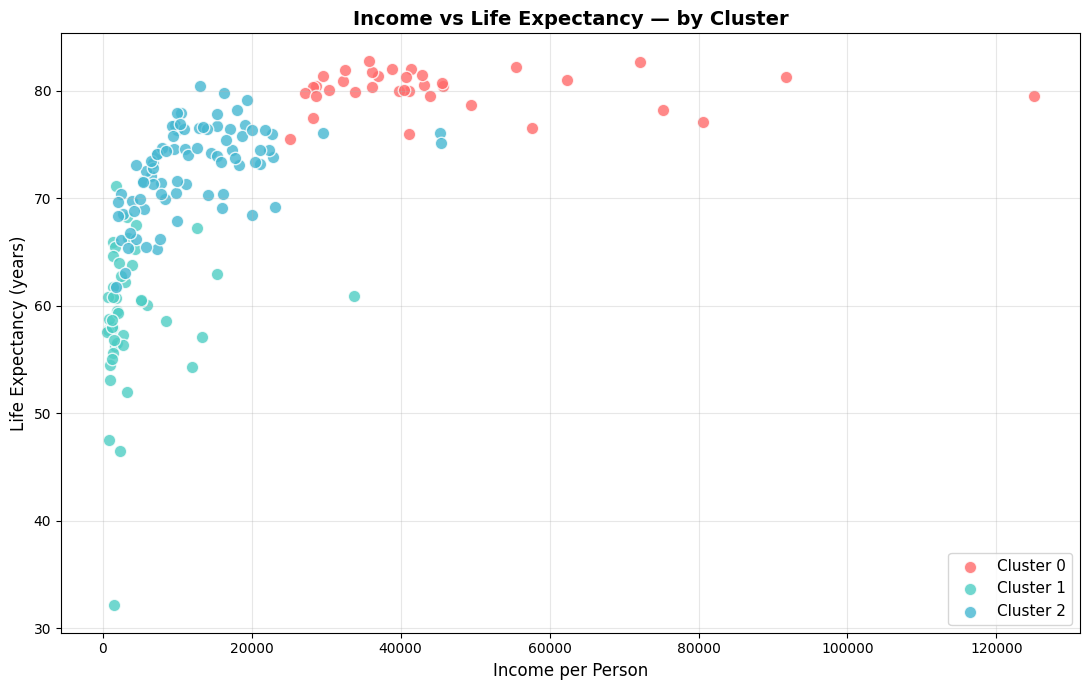

In [28]:
# Life Expectancy vs Income by Cluster
plt.figure(figsize=(11, 7))
for c in range(3):
    mask = df['KMeans_Cluster'] == c
    plt.scatter(df.loc[mask, 'income'], df.loc[mask, 'life_expec'],
                c=cluster_colors[c], label=cluster_label_names[c],
                s=80, alpha=0.8, edgecolors='white')

plt.xlabel('Income per Person', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title('Income vs Life Expectancy — by Cluster', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
# Top 10 countries per cluster by GDP
for c in range(3):
    cluster_countries = df[df['KMeans_Cluster'] == c].copy()
    cluster_countries['country'] = country_names[df['KMeans_Cluster'] == c]
    top10 = cluster_countries.nlargest(10, 'gdpp')[['country', 'gdpp', 'income', 'life_expec', 'child_mort']]
    print(f'\n Cluster {c} — Top 10 Countries by GDP:')
    print(top10.to_string(index=False))


 Cluster 0 — Top 10 Countries by GDP:
      country   gdpp  income  life_expec  child_mort
   Luxembourg 105000   91700        81.3         2.8
       Norway  87800   62300        81.0         3.2
  Switzerland  74600   55500        82.2         4.5
        Qatar  70300  125000        79.5         9.0
      Denmark  58000   44000        79.5         4.1
       Sweden  52100   42900        81.5         3.0
    Australia  51900   41400        82.0         4.8
  Netherlands  50300   45500        80.7         4.5
      Ireland  48700   45700        80.4         4.2
United States  48400   49400        78.7         7.3

 Cluster 1 — Top 10 Countries by GDP:
          country  gdpp  income  life_expec  child_mort
Equatorial Guinea 17100   33700        60.9       111.0
            Gabon  8750   15400        62.9        63.7
     South Africa  7280   12000        54.3        53.7
         Botswana  6350   13300        57.1        52.5
          Namibia  5190    8460        58.6        56.0
   

## Step 12: Conclusions & Summary

In [30]:
print('='*65)
print('       CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY')
print('='*65)

print('\n DATASET:')
print(f'   • {df.shape[0]} countries, {len(numerical_cols)} socio-economic features')

print('\n CLUSTERING RESULTS:')
print(f'   • K-Means (K=3) Silhouette Score: {silhouette_score(features_scaled, kmeans_labels):.4f}')
print(f'   • DBSCAN found {n_clusters_db} clusters with {n_noise} noise points')
print('   • 3 clear country segments identified: Developed / Developing / Underdeveloped')

print('\n CLASSIFICATION RESULTS:')
for model, scores in results.items():
    print(f'   • {model:<22}: Test = {scores["Test Acc"]*100:.2f}%  |  CV = {scores["CV Acc"]*100:.2f}%')

best_model = max(results, key=lambda m: results[m]['Test Acc'])
print(f'\n🏆 Best Model: {best_model} ({results[best_model]["Test Acc"]*100:.2f}% accuracy)')

print('\n KEY INSIGHTS:')
print('   • GDP per capita and Income are the most important features')
print('   • Child mortality strongly differentiates cluster groups')
print('   • Ensemble methods (RF, XGBoost) outperform single classifiers')
print('   • K-Means provides more stable clusters than DBSCAN on this data')

       CUSTOMER INTELLIGENCE SYSTEM — FINAL SUMMARY

 DATASET:
   • 167 countries, 9 socio-economic features

 CLUSTERING RESULTS:
   • K-Means (K=3) Silhouette Score: 0.2833
   • DBSCAN found 1 clusters with 30 noise points
   • 3 clear country segments identified: Developed / Developing / Underdeveloped

 CLASSIFICATION RESULTS:
   • Logistic Regression   : Test = 100.00%  |  CV = 93.99%
   • Decision Tree         : Test = 94.12%  |  CV = 90.97%
   • Random Forest         : Test = 100.00%  |  CV = 93.19%
   • XGBoost               : Test = 97.06%  |  CV = 93.93%

🏆 Best Model: Logistic Regression (100.00% accuracy)

 KEY INSIGHTS:
   • GDP per capita and Income are the most important features
   • Child mortality strongly differentiates cluster groups
   • Ensemble methods (RF, XGBoost) outperform single classifiers
   • K-Means provides more stable clusters than DBSCAN on this data
